In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.FashionMNIST(root="data",
                                   train=True,
                                   download=True,
                                   transform=ToTensor(),
                                   target_transform=None)
test_data = datasets.FashionMNIST(root="data",
                                  train=False,
                                  download=True,
                                  transform=ToTensor())



100%|██████████| 26.4M/26.4M [00:01<00:00, 17.7MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 310kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 5.68MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.38MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
len(train_data.data), len(train_data.targets), len(test_data.data),len(test_data.targets)

(60000, 60000, 10000, 10000)

In [ ]:
image, label = train_data[0]
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

image shape: torch.Size([1, 28, 28])


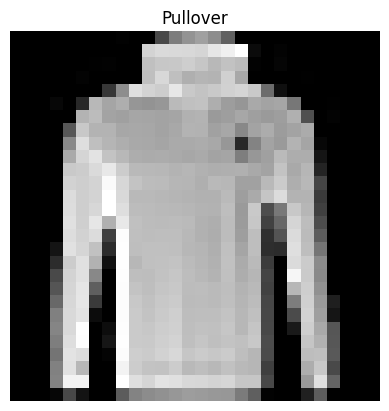

In [ ]:
image, label = train_data[7666]
print(f"image shape: {image.shape}")
plt.imshow(image.squeeze(), cmap= "gray")
plt.title(class_names[label])
plt.axis(False);

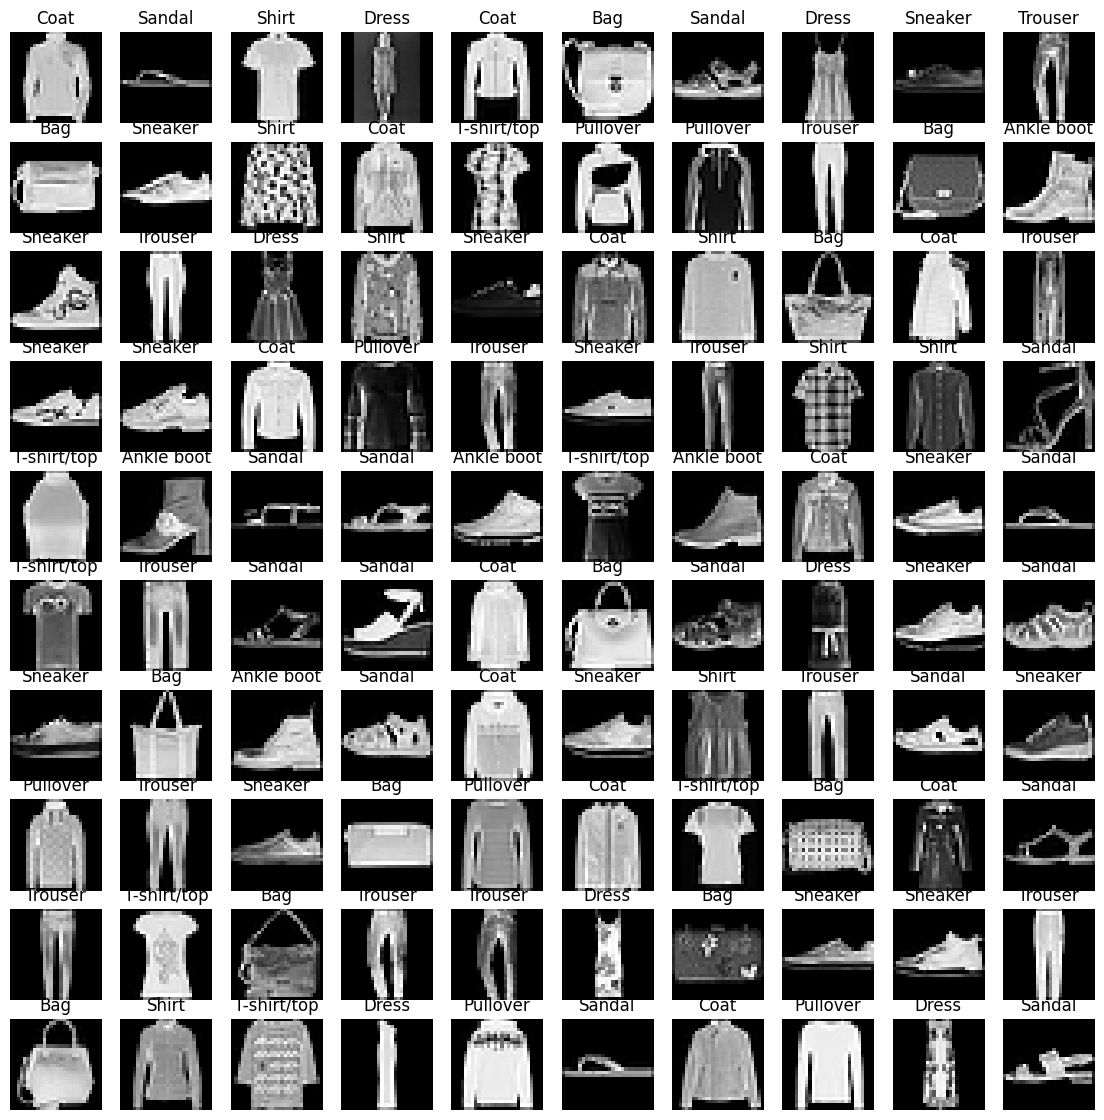

In [ ]:
fig = plt.figure(figsize=(14,14))
rows, cols = 10,10
for i in range(1, rows*cols + 1):
  rand_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[rand_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap= "gray")
  plt.title(class_names[label])
  plt.axis(False);


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size= BATCH_SIZE,
                              shuffle= True)
test_dataloader = DataLoader(test_data,
                             batch_size= BATCH_SIZE,
                             shuffle= False)


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
class FashionMNIST_cnn_model(nn.Module):
  def __init__(self, input_shape: int, output_shape: int, hidden_units: int):
    super().__init__()
    self.block1 = nn.Sequential(nn.Conv2d(input_shape,
                                          hidden_units,
                                          kernel_size=3,
                                          stride=1,
                                          padding=1),
                                nn.ReLU(),
                                nn.Conv2d(hidden_units,
                                          hidden_units,
                                          kernel_size=3,
                                          stride=1,
                                          padding=1),
                                nn.ReLU(),
                                nn.MaxPool2d(2))
    self.block2 = nn.Sequential(nn.Conv2d(hidden_units,
                                          hidden_units,
                                          kernel_size=3,
                                          stride=1,
                                          padding=1),
                                nn.ReLU(),
                                nn.Conv2d(hidden_units,
                                          hidden_units,
                                          kernel_size=3,
                                          stride=1,
                                          padding=1),
                                nn.ReLU(),
                                nn.MaxPool2d(2))
    self.classifier = nn.Sequential(nn.Flatten(),
                                    nn.Linear(in_features=hidden_units*7*7,
                                              out_features= output_shape))

  def forward(self, x: torch.Tensor)-> torch.Tensor:
    x= self.block1(x)
    x=self.block2(x)
    x=self.classifier(x)
    return x

model_2 = FashionMNIST_cnn_model(input_shape= 1,
                                 output_shape= len(class_names),
                                 hidden_units= 10
                                 )

model_2

FashionMNIST_cnn_model(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_2.parameters(),
                            lr=0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
  train_loss, train_acc = 0 ,0
  model.to(device)

  for batch, (X,y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss= loss_fn(y_pred, y)
    train_loss +=loss
    train_acc += accuracy_fn(y_true= y,
                            y_pred= y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /=len(data_loader)
  train_acc /=len(data_loader)

  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device):
  test_loss, test_acc = 0 ,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true= y,
                              y_pred= test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")




In [ ]:
epochs = 3
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n---------")
  train_step(model= model_2,
             data_loader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn= accuracy_fn,
             device= device)

  test_step(model= model_2,
            data_loader= test_dataloader,
            loss_fn= loss_fn,
            accuracy_fn= accuracy_fn,
            device= device)



Epoch: 0
---------
Train loss: 0.66266 | Train accuracy: 75.80%
Test loss: 0.40530 | Test accuracy: 85.26%

Epoch: 1
---------
Train loss: 0.36870 | Train accuracy: 86.76%
Test loss: 0.34756 | Test accuracy: 87.11%

Epoch: 2
---------
Train loss: 0.32946 | Train accuracy: 88.08%
Test loss: 0.33232 | Test accuracy: 87.97%



In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)

      pred_logit = model(sample)

      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)



In [ ]:
import random
##random.seed(493)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

In [ ]:
test_samples[0].shape, test_labels[0]

(torch.Size([1, 28, 28]), 3)

In [ ]:
pred_probs = make_predictions(model= model_2,
                              data= test_samples,
                              device= device)

pred_probs[:2]


tensor([[3.2981e-02, 5.3570e-04, 3.0504e-05, 9.6135e-01, 3.1357e-04, 7.9068e-06,
         4.3970e-03, 7.4451e-05, 2.4598e-04, 6.7077e-05],
        [6.9538e-08, 2.8243e-09, 6.5361e-08, 1.0133e-07, 1.0689e-06, 5.3873e-06,
         4.3493e-07, 3.5165e-04, 8.4127e-05, 9.9956e-01]])

In [ ]:
pred_classes = pred_probs.argmax(dim= 1)

pred_classes

tensor([3, 9, 9, 7, 1, 6, 0, 9, 5])

In [ ]:
test_labels, pred_classes

([3, 9, 9, 7, 1, 0, 0, 9, 5], tensor([3, 9, 9, 7, 1, 6, 0, 9, 5]))

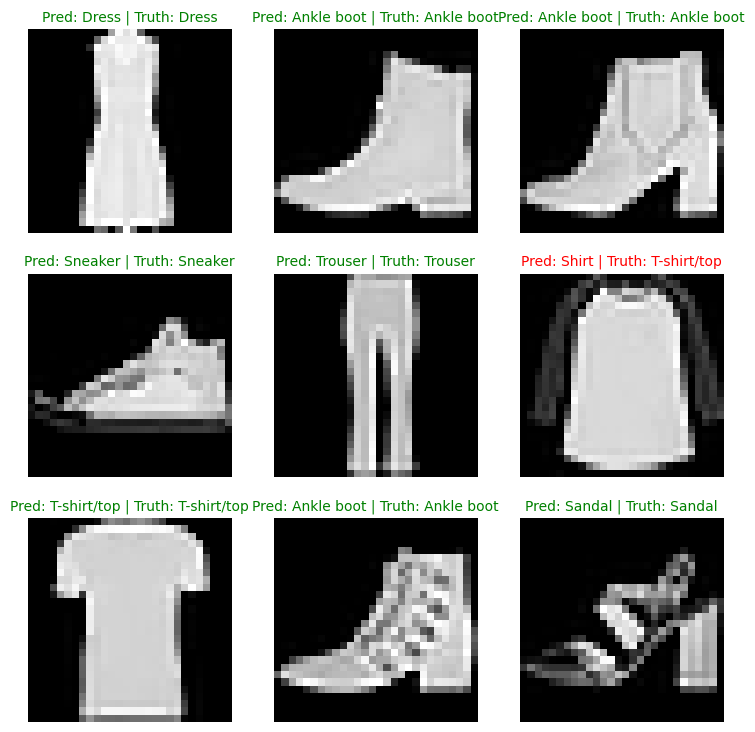

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);